---

# Single Neuron Model: The Perceptron

## Perceptron Theory

The Perceptron is a standard single neuron ML model that implements a binary sign activation function for decision-making and prediction.

<p align="center">
    <img src="https://github.com/RandyRDavila/Data_Science_and_Machine_Learning_Spring_2022/blob/main/Lecture_3/ThePerceptronImage.png?raw=1" width="500">
</p>

We will train and test this model on the Breast Cancer Tumor Cell dataset, compiled for prediction by Tanzeela Aftab on Kaggle:
https://www.kaggle.com/datasets/guriya79/breast-cancer

---

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Plotting Function
from mlxtend.plotting import plot_decision_regions

# Seaborn theme
sns.set_theme()

# Reading in the Smartphone Usage Dataset
df = pd.read_csv("/content/Breast_cancer_Reseach (1).csv")

In [40]:
df.iloc[:100]

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,perimeter_se,area_se,smoothness_se,radius_worst,texture_worst,perimeter_worst,area_worst,concavity_worst,concave_points_worst,diagnosis
0,15.490142,19.500898,75.565249,526.409677,0.110140,0.094296,0.211172,0.109355,0.114075,0.054322,...,2.462022,42.305337,0.011282,18.287341,22.645848,101.643449,980.949501,0.300743,0.116431,B
1,13.585207,17.282378,93.536417,542.133582,0.098852,0.118453,0.205202,0.146600,0.218061,0.065125,...,1.592161,32.253159,0.007029,13.874569,27.706897,120.003792,734.421427,0.292429,0.114310,B
2,15.943066,19.489190,79.066398,957.471814,0.072091,0.102897,0.265062,0.125013,0.185707,0.062901,...,3.109572,61.427110,0.007098,19.765426,23.100544,165.333024,865.634991,0.138234,0.221270,B
3,18.569090,21.173192,84.566898,650.102423,0.085842,0.122600,0.132492,0.093229,0.168611,0.060439,...,3.020457,54.395979,0.005667,14.638553,25.579304,101.911156,808.195350,0.218719,0.243221,M
4,13.297540,19.195440,123.469042,767.319500,0.094745,0.139292,0.060506,0.154095,0.205715,0.069305,...,2.027102,32.581794,0.007993,19.998220,25.872578,89.016818,987.071625,0.520519,0.103556,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9.609455,18.604441,106.264104,602.736990,0.099803,0.186912,0.166483,0.129653,0.156090,0.062688,...,0.954205,37.932456,0.008597,22.704937,18.376070,104.047127,506.263572,0.412573,0.168984,B
96,14.888361,22.676306,84.420741,564.238094,0.066230,0.092833,0.134031,0.121418,0.183717,0.044895,...,2.043181,38.622141,0.008831,19.290901,27.315692,143.481045,1251.298656,0.381499,0.170248,B
97,14.783166,17.838902,84.404797,699.891127,0.077599,0.154374,0.115296,0.148360,0.198449,0.053122,...,4.122261,31.643988,0.009528,12.475641,23.218493,107.338705,997.573367,0.212307,0.223014,B
98,14.015340,20.069569,105.807438,789.969211,0.113418,0.161652,0.142759,0.028805,0.216107,0.053230,...,2.908383,51.739009,0.007835,14.598212,27.873465,119.373087,709.614230,0.209780,0.150439,B


# Dataset Exploration: Daily Screen-Time and Stress Level


--- 
Missing Values per Column:
|                        |   0 |
|:-----------------------|----:|
| radius_mean            |   0 |
| texture_mean           |   0 |
| perimeter_mean         |   0 |
| area_mean              |   0 |
| smoothness_mean        |   0 |
| compactness_mean       |   0 |
| concavity_mean         |   0 |
| concave_points_mean    |   0 |
| symmetry_mean          |   0 |
| fractal_dimension_mean |   0 |
| radius_se              |   0 |
| texture_se             |   0 |
| perimeter_se           |   0 |
| area_se                |   0 |
| smoothness_se          |   0 |
| radius_worst           |   0 |
| texture_worst          |   0 |
| perimeter_worst        |   0 |
| area_worst             |   0 |
| concavity_worst        |   0 |
| concave_points_worst   |   0 |
| diagnosis              |   0 |

--- 


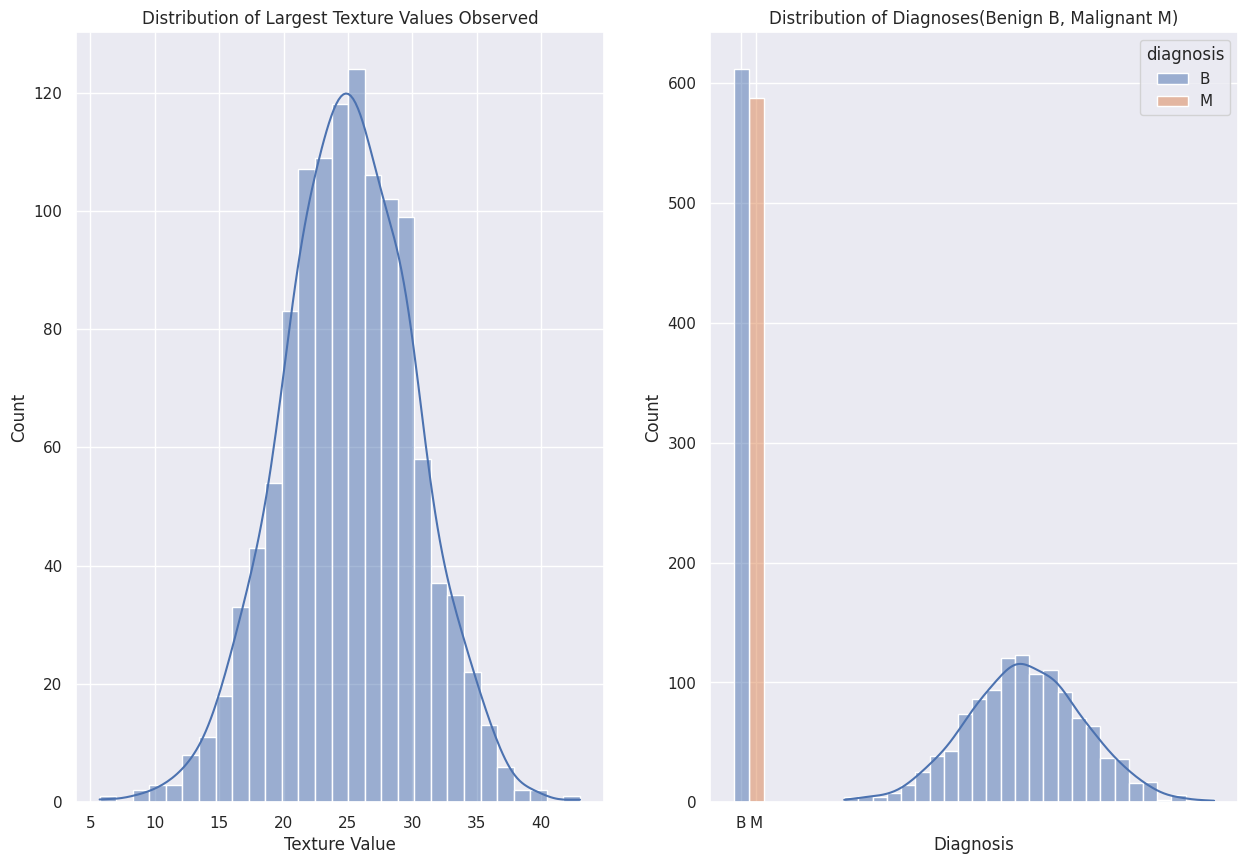

In [70]:
plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)
sns.histplot(df['texture_worst'], kde=True)
plt.title('Distribution of Largest Texture Values Observed')
plt.xlabel('Texture Value')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df['texture_mean'], kde=True)
plt.title('Distribution of Mean Texture Values Observed')
plt.xlabel('Texture Value')
plt.ylabel('Count')

plt.subplot(1,2,2)
sns.histplot(df, x = 'diagnosis', hue='diagnosis')
plt.title('Distribution of Diagnoses(Benign B, Malignant M)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

print("\n--- ")
print("Missing Values per Column:")
print(df.isnull().sum().to_markdown())
print("\n--- ")

# Preprocessing
Here, we will drop 'addiction_level' for missing values, 'addicted_label' for bias, and all id columns for relevance to prediction.

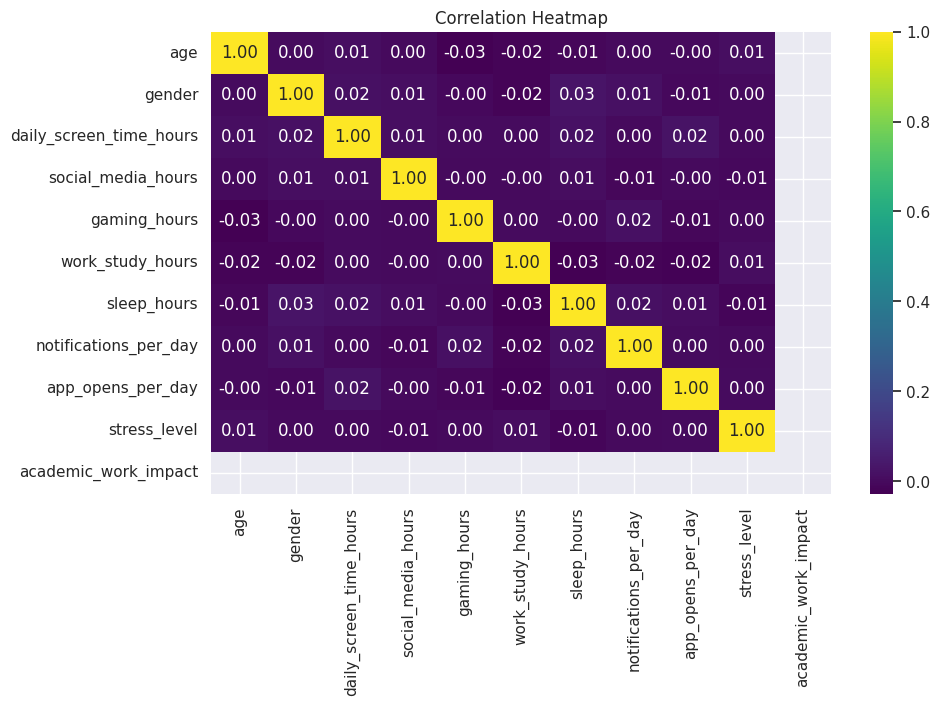

In [36]:
# Convert categorical variables to numerical
#   Gender: Female(0), Male(1)
df['gender'] = [1 if gender == 'Male' else 0 for gender in df['gender']]
df.head()

# Correlation Heatmap
corr_map = df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_map, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


---

The Perceptron is used on weighted binary decision problems, so we will use the labels, 'High' and 'Low', from the 'stress level' column below to train the model.

---

In [34]:
df.iloc[:100]['stress_level']

,stress_level
0,1
1,1
2,2
3,2
4,0
...,...
95,2
96,2
97,0
98,0


---

The perceptron can take in any number of feature measurments, but for simplicity we focus our attention on just two feature measurements, namely "sepal length" and "sepal width". Moreover, we need to also convert the string names associated with each species to numerical values; for example, map "setosa" species to -1 and "versicolor" species to 1. The following code preproccesses our data into these desired formats.

```python
# Store the desired species values in the numpy array y
y = df.iloc[0:100].species.values

# Convert each entry of y with setosa to -1 and otherwise 1
y = np.where(y == 'setosa', -1, 1)

# Store the desired feature measurements in the matrix X
X = df[["sepal_length", "sepal_width"]].iloc[:100].values
```

---

In [ ]:
# Store the desired species values in the numpy array y
y = df.iloc[0:100].species.values

# Convert each entry of y with setosa to -1 and otherwise 1
y = np.where(y == 'setosa', -1, 1)

# Store the desired feature measurements in the matrix X
X = df[["sepal_length", "sepal_width"]].iloc[:100].values

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.1],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3],
       [7. , 3.2],
       [6.4, 3.2],
       [6.9,

---

As mentioned in a previous lecture [python classes lecture](https://www.youtube.com/watch?v=qkbyE1vUl58&list=PLiUo37D6MN3Fc-lICEHyR46VfwynkIRrf&index=7), python classes store data as class attribute and functions as class methods. This framework is perfect for implementing a single neuron model. Thus, we next write a custom python class that stores a scaling value for the cost function, the number of epochs when training, the weights (and bias), and the errors incured during training on a given instance. Moreover, this python class will also contain a training method, a input method, and a predict method. Please run the following code in the cell below.

```python
class Perceptron(object):
    def __init__(self, eta = .5, epochs=50):
        self.eta = eta
        self.epochs = epochs
        
    def train(self, X, y):
        self.w_ = np.random.rand(1 + X.shape[1])
        
        self.errors_ = []
        
        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (self.predict(xi) - target)
                self.w_[:-1] -= update*xi
                self.w_[-1] -= update
                errors += int(update != 0)
            if errors == 0:
                return self
            else:
                self.errors_.append(errors)
            
        return self
    
    def net_input(self, X):
        return np.dot(X, self.w_[:-1]) + self.w_[-1]
    
    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)
```

---

In [ ]:
class Perceptron(object):
    def __init__(self, eta = .5, epochs=50):
        self.eta = eta
        self.epochs = epochs

    def train(self, X, y):
        self.w_ = np.random.rand(1 + X.shape[1])

        self.errors_ = []

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (self.predict(xi) - target)
                self.w_[:-1] -= update*xi
                self.w_[-1] -= update
                errors += int(update != 0)
            if errors == 0:
                return self
            else:
                self.errors_.append(errors)

        return self

    def net_input(self, X):
        return np.dot(X, self.w_[:-1]) + self.w_[-1]

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)


---

Next we can instantiate an instance of the ```Perceptron``` class and also train this instance over 1000 epochs by running the following code in the cell below.
```python
# Instantiate one instance of the Perceptron class
percep = Perceptron(epochs = 1000)

# Call the train method to train the weights and bias of the given instance
percep.train(X, y)
```

---

In [ ]:
# Instantiate one instance of the Perceptron class
clf = Perceptron(epochs = 100_000)

# Call the train method to train the weights and bias of the given instance
clf.train(X, y)

---

After training has finished we can call the ```Perceptron``` class ```predict``` method to view its current predictions given input features. We can quickly view these predictions on the entries in ```X``` by running the following code in the cell below.
```python
# Predict labels on the features in X
y_hat = percep.predict(X)

# Compare y_hat and y
print(y == y_hat)

```



---

In [ ]:
# Predict labels on the features in X
y_hat = clf.predict(X)

# Compare y_hat and y
print(y == y_hat)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True]


---

As we can see from the output of the code above, the predicted values have matched the true values on the given data. We can visualize this in the Euclidian plane by calling the ```plot_decision_regions``` function imported at the top of this notebook. This function will scatter the iris data in the plane and also show the regions of space where a given point will be classified either -1 or 1. It super easy to use and I'm glad I found it! Try running the following code in the cell below.
```python
plt.figure(figsize = (10, 8))
plot_decision_regions(X, y, clf = percep)
plt.title("My First Perceptron", fontsize = 18)
plt.xlabel("sepal length [cm]", fontsize = 15)
plt.ylabel("petal length [cm]", fontsize = 15)
plt.show()
```

---

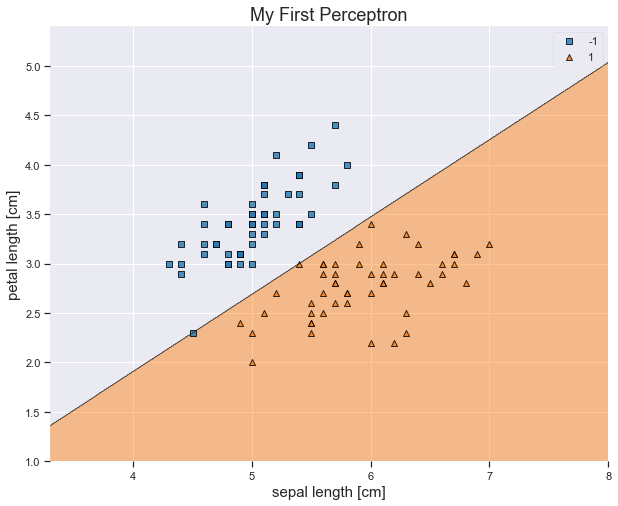

In [ ]:
plt.figure(figsize = (10, 8))
plot_decision_regions(X, y, clf = clf)
plt.title("My First Perceptron", fontsize = 18)
plt.xlabel("sepal length [cm]", fontsize = 15)
plt.ylabel("petal length [cm]", fontsize = 15)
plt.show()

---

As you can see from the output of the code above, we have found a nice linear seperator which has classified our data. But how long did our perceptron model train for? Luckily, when we defined our ```Perceptron``` class we stored the error incured by the model at each iteration of an epoch in the ```errors_``` attribute. We can view these errors over each epoch by running the following code in the cell below.
```python
plt.figure(figsize = (10, 8))
plt.plot(range(1, len(percep.errors_)+1), percep.errors_,
         marker = "o",
         label = "error plot",)
plt.xlabel("Iterations")
plt.ylabel("Missclassifications")
plt.legend()
plt.show()
```

---

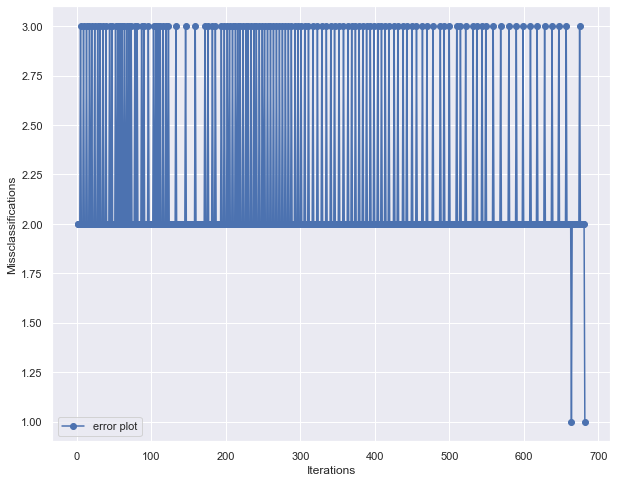

In [ ]:
plt.figure(figsize = (10, 8))
plt.plot(range(1, len(clf.errors_)+1), clf.errors_,
         marker = "o",
         label = "error plot",)
plt.xlabel("Iterations")
plt.ylabel("Missclassifications")
plt.legend()
plt.show()

---

# Conclusion

We have shown that the perceptron model works well on classifying these two species of iris flower. However, the data generated by these measurements and species was *linearly seperable*. What happens if the data is not linearly seperable? I encourage you to repeat each step of this notebook with the "versicolor" and "virginica" flowers and experiment with different possible measurements. Also, I have included the palmer penguins dataset in the Datasets folder. You should also try and implement the perceptron model on that data as well.


---